In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
# config 
VISION_RADIUS = 4
LOS = 'square360'
GRAZING = True # In case of Bresenham LOS, put grazing walls to False to match the LOS4 and LOS8 visibility maps. This is because Bresenham LOS already accounts for grazing walls in its visibil if required.ty calculation.

Generated Grid:


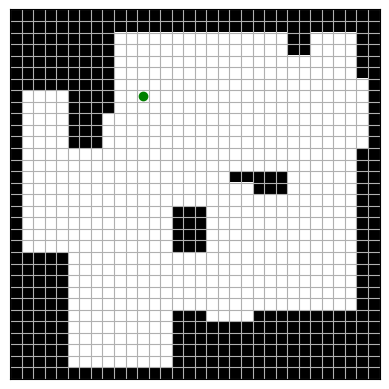

In [11]:
# Generate a random grid
gen = WRPDataGenerator(32, 32)
grid, start = gen.generate_valid_grid(density=5, clutter_proba=0.0, free_ratio_threshold=0.5)
# grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


Suboptimal Path Length: 88


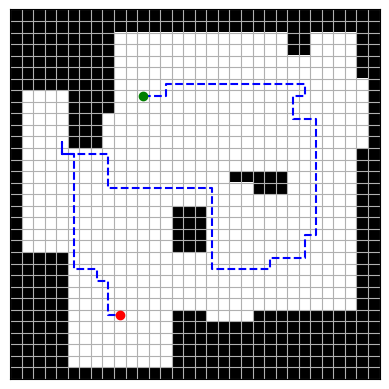

In [12]:
from wrp_solver_suboptimal import *
solver_opt = WRPSolverJF(grid, start, los_type=LOS,  vision_radius=VISION_RADIUS)
path_subopt, cnt_opt = solve_wrp_jf(solver_opt, weight = 4, df = 1.5, heuristic = "tsp")

print("Suboptimal Path Length:", len(path_subopt))

plot_path(grid, path_subopt, start)

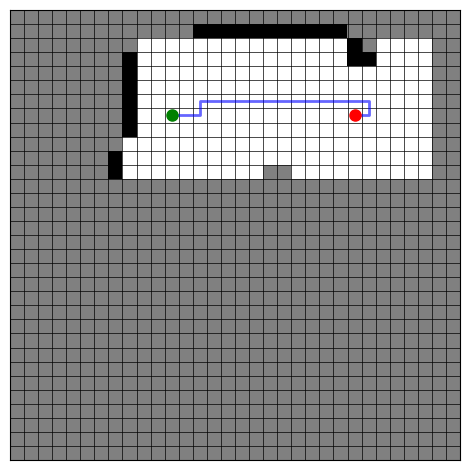

In [15]:
plot_visibility2(grid, path_subopt[:18], los_type=LOS, vision_radius=VISION_RADIUS, grazing_walls=GRAZING)

In [6]:
# from data_generator import _solve_grid
# def generate_N_training_data_for_online_learning(num_samples, grid_size=(16, 16), density=5, timeout=300):
#     X_list = []
#     y_list = []
#     skipped = 0
    
#     for _ in tqdm(range(num_samples)):
#         # Generate a random grid and path
#         gen = WRPDataGenerator(*grid_size)
#         # grid, start = gen.generate_valid_grid(density=density)
#         grid, start = gen.generate_simple_polygon_grid()
        
#         try:
#             path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start), timeout=timeout)
#         except TimeoutError:
#             skipped += 1
#             continue
        
#         # Generate training data from the path
#         X, y = generate_training_data_for_online_learning(grid, path_opt)
#         X_list.append(torch.tensor(X, dtype=torch.float32))
#         y_list.append(torch.tensor(y, dtype=torch.float32))
    
#     if skipped:
#         print(f"Skipped {skipped}/{num_samples} samples due to timeout ({timeout}s)")
    
#     return torch.cat(X_list), torch.cat(y_list)


In [16]:
X1, y1 = generate_training_data_for_online_learning(grid, path_subopt, grazing_walls = GRAZING, discounted_step=10, los_type=LOS, vision_radius=VISION_RADIUS)

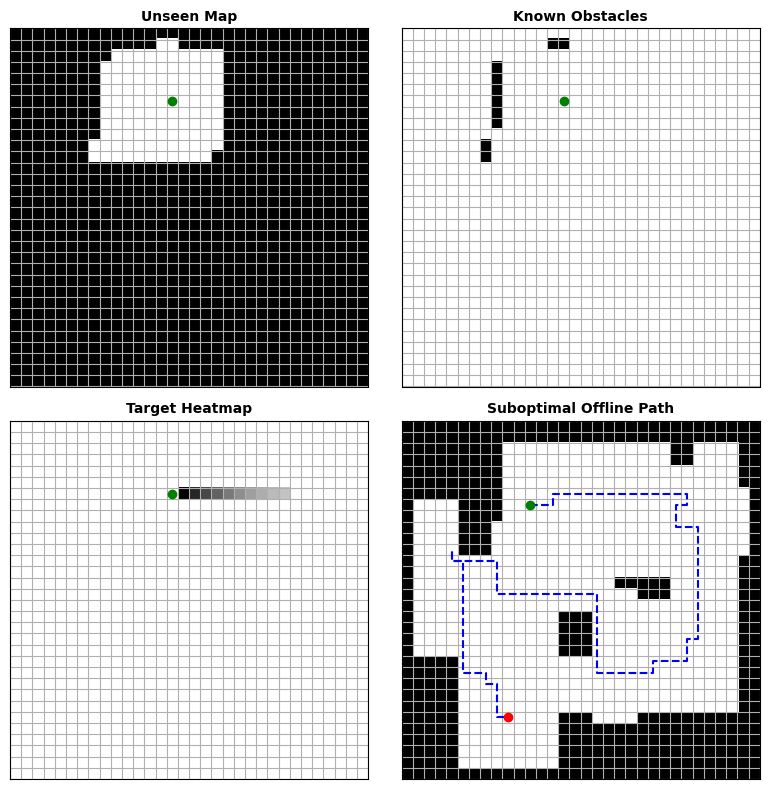

In [18]:
step = 4
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.ravel()

curr_loc_idx = X1[step][1].argmax(axis=None)
curr_loc = np.unravel_index(curr_loc_idx, X1[step][1].shape)

plt.sca(ax[0])
plot_grid(X1[step][2], curr_loc)
ax[0].set_title("Unseen Map", fontsize=10, fontweight="bold")

plt.sca(ax[1])
plot_grid(X1[step][0], curr_loc)
ax[1].set_title("Known Obstacles", fontsize=10, fontweight="bold")



plt.sca(ax[2])
plot_grid(y1[step][0], curr_loc)
ax[2].set_title("Target Heatmap", fontsize=10, fontweight="bold")


plt.sca(ax[3])
plot_path(grid, path_subopt, start)
ax[3].set_title("Suboptimal Offline Path", fontsize=10, fontweight="bold")


plt.tight_layout()
plt.show()

In [28]:
def generate_N_training_data_for_online_learning_from_npy_gt(folder_path, discounted_step = 0, grazing_walls=True, los_type = LOS, vision_radius = VISION_RADIUS, timeout=600):
    X_list = []
    y_list = []
    skipped = 0
    
    folder_paths = sorted(os.listdir(folder_path))
    total_files_processed = 0
    for npyfile in tqdm(folder_paths):
        if (npyfile[-4:]!=".npy"): continue

        npyfilePath = os.path.join(folder_path, npyfile)
        gt_data = np.load(npyfilePath, allow_pickle=True).item()
        grid = gt_data["grid"]
        start = gt_data["start"]
        path_subopt = gt_data["path_opt"]
        
        # Generate training data from the path
        X, y = generate_training_data_for_online_learning(grid, path_subopt, discounted_step=discounted_step, grazing_walls=grazing_walls, los_type=los_type, vision_radius=vision_radius)
        X_list.append(torch.tensor(X, dtype=torch.float32))
        y_list.append(torch.tensor(y, dtype=torch.float32))
        total_files_processed += 1
    
    if skipped:
        print(f"Skipped {skipped}/{len(folder_paths)} samples due to timeout ({timeout}s)")
    print(f"Processed {total_files_processed}/{len(folder_paths)} files.")
    return torch.cat(X_list), torch.cat(y_list)

X_train, y_train = generate_N_training_data_for_online_learning_from_npy_gt("data/DungeonMaps/train", discounted_step=10, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)
# X_test, y_test = generate_N_training_data_for_online_learning_from_npy_gt("data/DungeonMaps/test", discounted_step=10, grazing_walls=GRAZING, los_type=LOS, vision_radius=VISION_RADIUS, timeout=600)


100%|██████████| 7438/7438 [02:15<00:00, 54.85it/s]  


Processed 1774/7438 files.


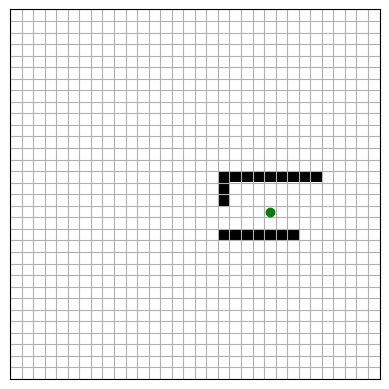

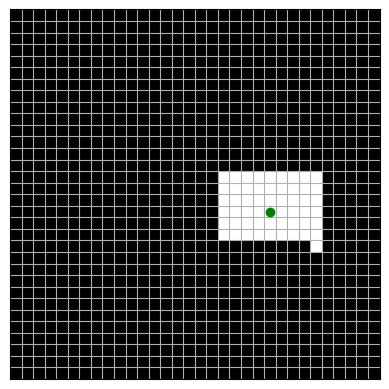

In [29]:
ind = 0
plot_grid(X_train[ind][0], np.where(X_train[ind][1] == 1.0))
plt.show()
plot_grid(X_train[ind][2], np.where(X_train[ind][1] == 1.0))
plt.show()

In [30]:
from data_generator import augment_data
X_train_aug, y_train_aug = augment_data(X_train, y_train)
# X_test_aug, y_test_aug = augment_data(X_test, y_test)
print("Augmented training data shapes:", X_train_aug.shape, y_train_aug.shape)
# print("Augmented test data shapes:", X_test_aug.shape, y_test_aug.shape)

Augmented training data shapes: torch.Size([603264, 3, 32, 32]) torch.Size([603264, 1, 32, 32])


In [26]:
model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1)
dummy_input = torch.randn(1, 3, 32, 32)
dummy_noisy_path = torch.randn(1, 1, 32, 32)
dummy_t = torch.randn(1)  # Assuming time embedding dimension is 128
output = model(dummy_input, dummy_noisy_path, dummy_t)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}") 

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 1, 32, 32])


In [31]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

def train_flow_matching_unet(X_train, y_train, X_val, y_val, model, num_epochs=50, batch_size=32, lr=1e-3, device=DEVICE):
    print(f"Training Flow Matching U-Net on: {device}")
    model = model.to(device)

    # Initialize the EMA Model
    ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.999))

    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print("Pre-computing fixed validation noise and time...")
    fixed_val_data = []
    for batch_X, batch_y in val_loader:
        b_size = batch_X.size(0)
        fixed_x_0 = torch.randn_like(batch_y)
        # Stratified time sampling
        fixed_t = torch.linspace(0.01, 0.99, b_size) 
        fixed_t = fixed_t[torch.randperm(b_size)] 
        fixed_val_data.append((batch_X, batch_y, fixed_x_0, fixed_t))

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # Calculate total batches for the OneCycleLR
    total_steps = num_epochs * len(train_loader)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=lr, 
        total_steps=total_steps,
        pct_start=0.1,  # Spend 10% of training warming up
        anneal_strategy='cos'
    )
    
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss_accum = 0.0 # Changed name slightly for clarity

        for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            batch_X, x_1 = batch_X.to(device), batch_y.to(device)
            batch_size_current = batch_X.size(0)

            # --- CFG Context Dropout (UNCOMMENTED) ---
            # drop = (torch.rand(batch_size_current, device=device) < 0.10).view(-1, 1, 1, 1)
            # batch_X = torch.where(drop, torch.zeros_like(batch_X), batch_X) 

            # Generate Pure Noise & Time
            x_0 = torch.randn_like(x_1)
            t = torch.rand(batch_size_current, device=device)
            # normal_noise = torch.randn(batch_size_current, device=device)
            # t = torch.sigmoid(normal_noise)
            t_expanded = t.view(batch_size_current, 1, 1, 1)

            # Rectified Flow Interpolation
            x_t = (t_expanded * x_1) + ((1.0 - t_expanded) * x_0)
            target_velocity = x_1 - x_0

            # Forward & Optimize
            optimizer.zero_grad()
            predicted_velocity = model(batch_X, noisy_path=x_t, t=t)
            
            loss = F.mse_loss(predicted_velocity, target_velocity)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            scheduler.step()

            # EMA Update
            ema_model.update_parameters(model)

            train_loss_accum += loss.item() * batch_size_current

        # ---------------------------
        # VALIDATION PHASE (Using EMA Model)
        # ---------------------------
        ema_model.eval()
        val_loss_accum = 0.0

        with torch.no_grad():
            for batch_X, batch_y, fixed_x_0, fixed_t in fixed_val_data:
                batch_X, x_1 = batch_X.to(device), batch_y.to(device)
                x_0 = fixed_x_0.to(device)
                t = fixed_t.to(device)
                
                batch_size_current = batch_X.size(0)
                t_expanded = t.view(batch_size_current, 1, 1, 1)

                x_t = (t_expanded * x_1) + ((1.0 - t_expanded) * x_0)
                target_velocity = x_1 - x_0

                # Validate using the EMA model
                predicted_velocity = ema_model(batch_X, noisy_path=x_t, t=t)
                loss = F.mse_loss(predicted_velocity, target_velocity)
                
                val_loss_accum += loss.item() * batch_size_current

        # --- LOGGING FIX: Calculate Epoch Averages and Append ---
        epoch_train_loss = train_loss_accum / len(train_loader.dataset)
        epoch_val_loss = val_loss_accum / len(val_loader.dataset)
        
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"LR: {scheduler.get_last_lr()[0]:.6f} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"EMA Val Loss: {epoch_val_loss:.4f}")

        # Save the best EMA model
        if epoch_val_loss <= best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(ema_model.module.state_dict(), 'best_wrp_flow_model_ema.pth')

        

    print("Training Complete.")
    return ema_model.module, train_losses, val_losses

In [33]:
#siple split train test from X_train_aug, y_train_aug, X_test_aug, y_test_aug

X_train_final, y_train_final = X_train_aug[:500000], y_train_aug[:500000]
X_val_final, y_val_final = X_train_aug[500000:600000], y_train_aug[500000:600000]


In [34]:
model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1)
trained_model, train_losses, val_losses = train_flow_matching_unet(X_train_final, y_train_final, X_val_final, y_val_final, model, num_epochs=10, batch_size=64, lr=1e-3)

Training Flow Matching U-Net on: mps
Pre-computing fixed validation noise and time...


Epoch 1/10: 100%|██████████| 7813/7813 [11:45<00:00, 11.08it/s]


Epoch [1/10] LR: 0.001000 | Train Loss: 0.0261 | EMA Val Loss: 0.0045


Epoch 2/10: 100%|██████████| 7813/7813 [11:02<00:00, 11.79it/s]


Epoch [2/10] LR: 0.000970 | Train Loss: 0.0046 | EMA Val Loss: 0.0032


...

Epoch [8/10] LR: 0.000117 | Train Loss: 0.0024 | EMA Val Loss: 0.0023


Epoch 9/10: 100%|██████████| 7813/7813 [11:44<00:00, 11.09it/s]


Epoch [9/10] LR: 0.000030 | Train Loss: 0.0023 | EMA Val Loss: 0.0023


Epoch 10/10: 100%|██████████| 7813/7813 [11:57<00:00, 10.89it/s]


Epoch [10/10] LR: 0.000000 | Train Loss: 0.0022 | EMA Val Loss: 0.0023
Training Complete.


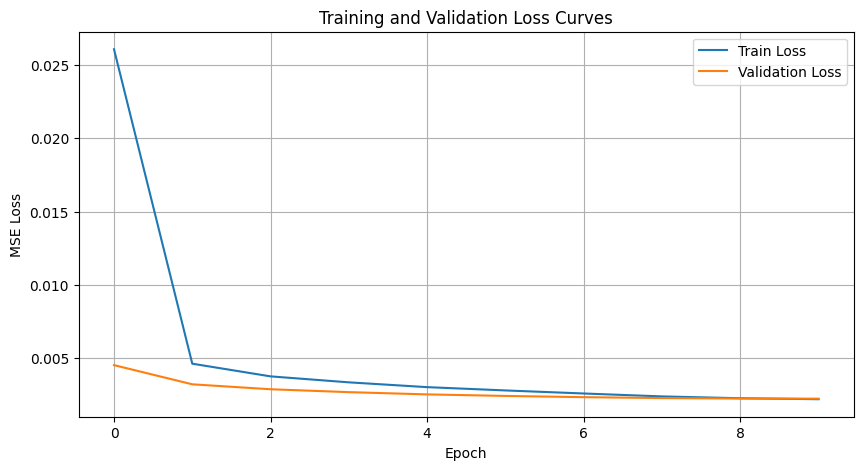

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch') 
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid()
plt.show()

In [37]:
trained_model.to("cpu")  # Move to CPU before saving for broader compatibility
torch.save(trained_model.state_dict(), f"model_grazing_flow_matching_32x32_los_{LOS}_vision_{VISION_RADIUS}_ResAttARUnet_batch64_lr1e3_1.pth")
trained_model.to(DEVICE)

FlowMatchingUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (inc): ResidualConvWithTime(
    (norm1): GroupNorm(6, 6, eps=1e-05, affine=True)
    (conv1): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=128, bias=True)
    )
    (shortcut): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): ResidualConvWithTime(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1):

In [ ]:
trained_model = FlowMatchingUNet(context_channels=3, path_channels=1, out_channels=1)
#LAst good : model_grazing_flow_matching_16x16_los_square360_vision_8_ResAttARUnet_batch64_lr1e3_6
#LAst good : model_grazing_flow_matching_16x16_los_square360_vision_8_ResAttARUnet_batch64_lr1e3_16

model_state_dict = torch.load("model_grazing_flow_matching_16x16_los_square360_vision_8_ResAttARUnet_batch64_lr1e3_16.pth")
trained_model.load_state_dict(model_state_dict)
trained_model.to(DEVICE)

FlowMatchingUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (inc): ResidualConvWithTime(
    (norm1): GroupNorm(6, 6, eps=1e-05, affine=True)
    (conv1): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (time_mlp): Sequential(
      (0): SiLU()
      (1): Linear(in_features=128, out_features=128, bias=True)
    )
    (shortcut): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): ResidualConvWithTime(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1):

In [38]:
@torch.no_grad()
def generate_flow_heatmap(model, context_tensor, inference_steps=40, cfg_scale=1.0, device=DEVICE):
    """
    Solves the Rectified Flow ODE to generate the final path heatmap.
    inference_steps: How many times to query the U-Net. 5 is usually plenty for straight-line ODEs!
    """
    context_tensor = context_tensor.to(device)
    empty_context = torch.zeros_like(context_tensor)
    b, c, h, w = context_tensor.shape
    
    # 1. Start with pure random noise (x_0)
    x_t = torch.randn((b, 1, h, w), device=device)
    
    # The size of our time step
    dt = 1.0 / inference_steps
    
    # 2. Iteratively sculpt the noise into the path
    for i in range(inference_steps):
        # Current time t
        t_val = i / inference_steps
        t_tensor = torch.full((b,), t_val, device=device)
        
        with torch.no_grad():
            # Pass 1: Conditional (The model sees the maze walls)
            v_cond = model(context_tensor, noisy_path=x_t, t=t_tensor)
            
            # Pass 2: Unconditional (The model sees nothing)
            if cfg_scale > 1.0:
                v_uncond = model(empty_context, noisy_path=x_t, t=t_tensor)
                velocity = v_uncond + cfg_scale * (v_cond - v_uncond)
                
            else:
                velocity = v_cond
            
        # Euler Step
        x_t = x_t + (velocity * dt)
        # plot_output_tensor(x_t[0])

        
    # After the loop, x_t has reached t=1.0 and is our final sculpted heatmap!
    return x_t




def generate_flow_heatmap_grad(model, context_tensor, inference_steps=40, cfg_scale=1.0, reward_scale=4.0, device=DEVICE):
    """
    Solves the Rectified Flow ODE using BOTH Classifier-Free Guidance and Reward Guidance.
    reward_scale: How hard the path is pulled toward the fog/unseen areas.
    """
    model.eval()
    b, c, h, w = context_tensor.shape
    
    # Extract the Fog Channel (Assuming it is channel index 2)
    # If your fog is on a different index, change this!
    fog_channel = context_tensor[:, 2:3, :, :].to(device)
    
    # 1. Start with pure random noise
    x_t = torch.randn((b, 1, h, w), device=device)
    empty_context = torch.zeros_like(context_tensor)
    dt = 1.0 / inference_steps
    
    for i in range(inference_steps):
        t_val = i / inference_steps
        t_tensor = torch.tensor([t_val], device=device)
        
        # --- THE MAGIC: Enable gradients during INFERENCE ---
        with torch.enable_grad():
            # Tell PyTorch to track the math applied to our noisy image
            x_t = x_t.detach().requires_grad_(True)
            
            # Pass 1 & 2: Conditional and Unconditional for CFG
            v_cond = model(context_tensor, noisy_path=x_t, t=t_tensor)
            if cfg_scale > 1.0:
                v_uncond = model(empty_context, noisy_path=x_t, t=t_tensor)
                # Standard Classifier-Free Guidance (Obey the walls)
                v_cfg = v_uncond + cfg_scale * (v_cond - v_uncond)
            else:
                v_cfg = v_cond
            # ---------------------------------------------------------
            # NEW: REWARD GUIDANCE (Hunt the Fog)
            # ---------------------------------------------------------
            # A. Estimate the final path (x_1) using the Rectified Flow equation
            x_1_hat = x_t + (1.0 - t_val) * v_cfg
            
            # B. Calculate Reward: Dot product of the estimated path and the Fog channel
            # This mathematically rewards paths that overlap with 1.0s in the fog tensor
            reward = torch.sum(x_1_hat * fog_channel)
            
            # C. Calculate the gradient: How do we change x_t to maximize the reward?
            grad_reward = torch.autograd.grad(reward, x_t)[0]
            
        # ---------------------------------------------------------
        # FINAL NUDGE: Add the reward gradient to the velocity!
        # ---------------------------------------------------------
        velocity = v_cfg + (reward_scale * grad_reward)
        
        # Euler Step (Detach to prevent memory leaks from the gradient graph)
        x_t = (x_t + velocity * dt).detach()
        
    # raw_heatmap = x_t.cpu().numpy()[0, 0]
    return torch.clamp(x_t, 0.0, 1.0)

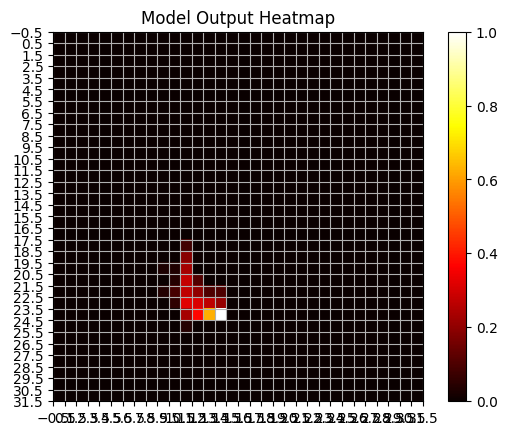

In [40]:
MODEL_RUN = 8
ind = 19

context = X_val_final[ind:ind+1].to(DEVICE)                  
context_batch = context.repeat(MODEL_RUN, 1, 1, 1)    

samples = generate_flow_heatmap(trained_model, context_batch, inference_steps=20, cfg_scale=1.0, device=DEVICE)
averaged = samples.mean(dim=0, keepdim=True)       

plot_output_tensor(averaged)

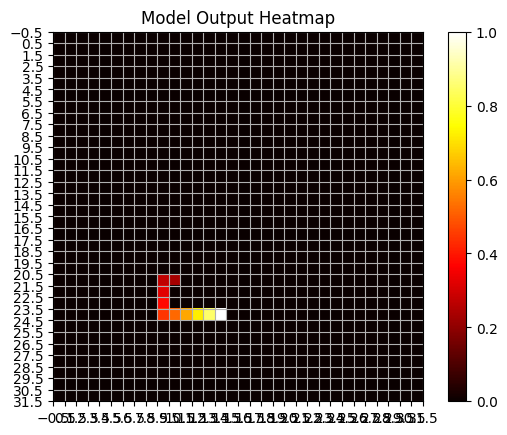

In [41]:
plot_output_tensor(y_val_final[ind])

In [14]:
## Testing

## Testing

In [ ]:
N_RUN = 16

def pred_path_greedy_online_flow(model, grid, start, max_steps=256, verbose=True, los_type='square', vision_radius=8.0):
    model.eval()
    current_pos = start
    path = [current_pos]
    H, W = grid.shape
    visited_counts = np.zeros((H, W))
    visited_counts[start[0], start[1]] = 1
    dataX =[]
    dataY =[]
    
    for step_idx in range(max_steps):
        # 1. Create input tensor for the current state (Unchanged)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        agent_position = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)  
        
        agent_position[current_pos] = 1.0
        
        # Raycast (ensure get_visibility_map_with_LOS matches your new functions)
        grazing_los = get_visibility_map_with_LOS(grid, path, grazing_walls=True, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=True)
        unseen_map[grazing_los == 1] = 0.0
        visible_walls = (grazing_los == 1) & (grid == 1)
        known_obstacles[visible_walls] = 1.0

        # Frontier Check (Unchanged)
        is_done = True
        for r in range(H):
            for c in range(W):
                if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0: 
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                            is_done = False  
                            break
                if not is_done: break
            if not is_done: break
            
        if is_done:
            if verbose:
                print(f"Success! Entire polygon explored in {step_idx} steps.")
            break

        # 2. Context Preparation
        state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
        state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # 3. THE FLOW MATCHING UPGRADE
        # Generate the heatmap by solving the ODE
        
        state_tensor_batched = state_tensor.repeat(N_RUN, 1, 1, 1)
        samples = generate_flow_heatmap(model, state_tensor_batched)
        pred = (samples.mean(dim=0)).cpu().numpy()[0]  # Average over runs and remove batch dimension
        

        # 4. Physically Constrained Action Selection
        neighbors = [
            (current_pos[0]-1, current_pos[1]), # Up
            (current_pos[0]+1, current_pos[1]), # Down
            (current_pos[0], current_pos[1]-1), # Left
            (current_pos[0], current_pos[1]+1)  # Right
        ]
        
        best_prob = -float('inf')
        best_next_pos = current_pos
        
        for r, c in neighbors:
            if 0 <= r < H and 0 <= c < W:
                if known_obstacles[r, c] != 1.0: # Don't walk into known walls
                    # Because we trained on a discounted 10-step horizon,
                    # the immediate correct step will naturally be the brightest pixel!
                    prob = pred[r, c]
                    penalty = visited_counts[r, c] * 0.4  # Keeps the agent from stalling
                    score = prob - penalty
                    
                    if score > best_prob:
                        best_prob = score
                        best_next_pos = (r, c)
                        
        if best_next_pos == current_pos:
            print(f"Model predicted to stay in place at step {step_idx}. Ending path.")
            break
        
        path.append(best_next_pos)
        current_pos = best_next_pos
        visited_counts[current_pos[0], current_pos[1]] += 1
        dataX.append(state_tensor.cpu().numpy())
        dataY.append(pred)
    return path, (dataX, dataY)


import numpy as np
import torch
import heapq

def local_astar(start, goal, known_obstacles):
    """
    Standard A* that ONLY routes through known free space.
    """
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])
        
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}
    
    while open_set:
        current = heapq.heappop(open_set)[1]
        
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.reverse()
            return path # Returns the path EXCLUDING the start node
            
        for dr, dc in neighbors:
            neighbor = (current[0] + dr, current[1] + dc)
            
            if 0 <= neighbor[0] < known_obstacles.shape[0] and 0 <= neighbor[1] < known_obstacles.shape[1]:
                if known_obstacles[neighbor[0], neighbor[1]] == 1.0:
                    continue
                    
                tentative_g_score = g_score[current] + 1
                
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
                    
    return None

def receding_horizon_astar_online(model, grid, start, max_steps=1000, verbose = True, los_type = LOS, vision_radius = VISION_RADIUS):
    model.eval()
    current_pos = start
    path = [current_pos]
    H, W = grid.shape
    
    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        grazing_los = get_visibility_map_with_LOS(grid, path, grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=True)
        unseen_map[grazing_los == 1] = 0.0
        visible_walls = grazing_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0

        
        # 2. Your Exact Termination Condition
        # explored = 1 - get_LOS4_visibility_map(grid, path, with_last_obstacle=False)
        # if (explored == grid).all():
        #     if verbose:
        #         print(f"Success! Entire grid explored optimally in {step} steps.")
        #     break
            
        current_unseen_count = unseen_map.sum()

        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            state_tensor_batched = state_tensor.repeat(N_RUN, 1, 1, 1)
            samples = generate_flow_heatmap(model, state_tensor_batched)
            pred = (samples.mean(dim=0)).cpu().numpy()[0]  # Average over runs and remove batch dimension
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                if verbose:
                    print(f"Success! Entire polygon explored in {step} steps.")
                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue

                # --- NEW: Information Gain (Guaranteed Area) ---
                # Dynamically simulate vision based on the active LOS settings
                sim_los = get_visibility_map_with_LOS(known_obstacles, [f], grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=False)

                # The gain is strictly the overlap between what the agent *would* see 
                # and the fog that is *currently* unseen.
                simulated_gain = np.sum((sim_los == True) & (unseen_map == 1.0))
                # ------------------------------------------------------
                if simulated_gain == 0:
                    continue  # Skip frontiers that provide no new information
                    
                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # TWEAK: Increased the distance penalty from 0.01 to 0.05
                    # This stops the agent from walking across the map for a 1% probability gain
                    # score = prob - 0.05 * distance #prob * simulated_gain/distance 

                    path_prob_sum = sum(pred[r, c] for r, c in local_path)
                    avg_path_prob = path_prob_sum / distance
                    normalized_dist = distance / (H + W)
                    score = avg_path_prob - (0.2 * distance)
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path


def receding_horizon_astar_online2(model, grid, start, max_steps=1000, verbose = True, los_type = LOS, vision_radius = VISION_RADIUS):
    model.eval()
    current_pos = start
    path = [current_pos]
    H, W = grid.shape

    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        expanded_los = get_visibility_map_with_LOS(grid, path, grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=True)

        grazing_los = apply_grazing_los(grid, expanded_los)
        unseen_map[grazing_los == 1] = 0.0
        visible_walls = grazing_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # 2. Your Exact Termination Condition
        explored = 1 - get_visibility_map_with_LOS(grid, path, grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=False)
        if (explored == grid).all():
            if verbose:
                print(f"Success! Entire grid explored optimally in {step} steps.")
            break

        current_unseen_count = unseen_map.sum()

        
        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            state_tensor_batched = state_tensor.repeat(N_RUN, 1, 1, 1)
            samples = generate_flow_heatmap(model, state_tensor_batched)
            pred = (samples.mean(dim=0)).cpu().numpy()[0]  # Average over runs and remove batch dimension
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                print(f"Success! Entire polygon explored in {step} steps.")
                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue

                # --- NEW: Information Gain (Guaranteed Area) ---
                # Dynamically simulate vision based on the active LOS settings
                sim_los = get_visibility_map_with_LOS(known_obstacles, [f], grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=False)

                # The gain is strictly the overlap between what the agent *would* see 
                # and the fog that is *currently* unseen.
                simulated_gain = np.sum((sim_los == True) & (unseen_map == 1.0))
                # ------------------------------------------------------
                if simulated_gain == 0:
                    continue  # Skip frontiers that provide no new information
                    
                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # TWEAK: Increased the distance penalty from 0.01 to 0.05
                    # This stops the agent from walking across the map for a 1% probability gain
                    # score = prob - 0.05 * distance #prob * simulated_gain/distance 

                    path_prob_sum = sum(pred[r, c] for r, c in local_path)
                    avg_path_prob = path_prob_sum / distance
                    normalized_dist = distance / (H + W)
                    score = avg_path_prob - (0.2 * distance)
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path


def hipps_algorithm(grid, start, max_steps=1000, verbose = True, los_type = LOS, vision_radius = VISION_RADIUS):
    current_pos = start
    path = [current_pos]
    
    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        grazing_los = get_visibility_map_with_LOS(grid, path, grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=True)
        unseen_map[grazing_los == 1] = 0.0
        visible_walls = grazing_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # 2. Your Exact Termination Condition
        # explored = 1 - get_LOS4_visibility_map(grid, path, with_last_obstacle=False)
        # if (explored == grid).all():
        #     if verbose:
        #         print(f"Success! Entire grid explored optimally in {step} steps.")
        #     break
            
        current_unseen_count = unseen_map.sum()

        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            # with torch.no_grad():
            #     pred = model(state_tensor).cpu().numpy()[0, 0]
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                if verbose:
                    print(f"Success! Entire polygon explored in {step} steps.")
                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue
                    
                 # --- NEW: Information Gain (Guaranteed Area) ---
                # Dynamically simulate vision based on the active LOS settings
                sim_los = get_visibility_map_with_LOS(known_obstacles, [f], grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=False)

                # The gain is strictly the overlap between what the agent *would* see 
                # and the fog that is *currently* unseen.
                simulated_gain = np.sum((sim_los == True) & (unseen_map == 1.0))
                # ------------------------------------------------------

                if simulated_gain == 0:
                    continue  # Skip frontiers that provide no new information

                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    # prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # --- THE NEW IPP HEURISTIC ---
                    # Weight the U-Net's probability by the immediate mapping gain,
                    # then apply the linear physical distance tax.
                    score = (simulated_gain) / ( distance)
                    # -----------------------------
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path

img_10602.png


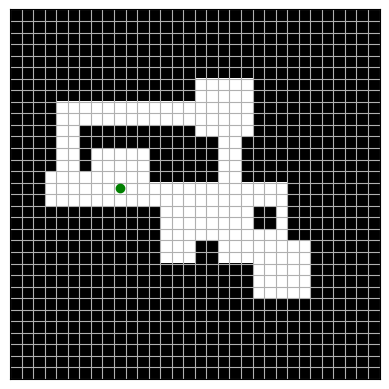

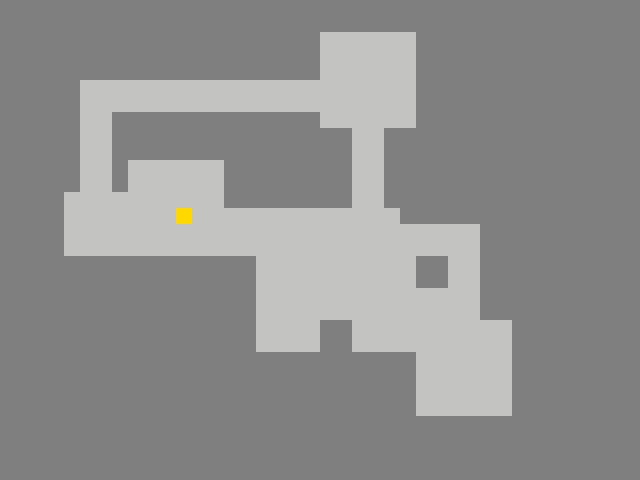

In [90]:
from dungeon_map import *
from PIL import Image

files = os.listdir("data/DungeonMaps/test")
ind = np.random.randint(0, len(files))
print(files[ind])
grid, start = image_to_grid2(os.path.join("data/DungeonMaps/test", files[ind]))

# gen = WRPDataGenerator(32, 32)
# # grid, start = gen.generate_simple_polygon_grid()
# grid, start = gen.generate_valid_grid(density=5, clutter_proba=0.0, free_ratio_threshold=0.5)

plot_grid(grid, start)  # Plot the grid from the first channel of the input
plt.show()
img = Image.open(os.path.join("data/DungeonMaps/test", files[ind]))
img
# img.show()  # Show the original image for reference

Success! Entire polygon explored in 61 steps.
Success! Entire polygon explored in 44 steps.
Success! Entire polygon explored in 145 steps.
Success! Entire polygon explored in 76 steps.


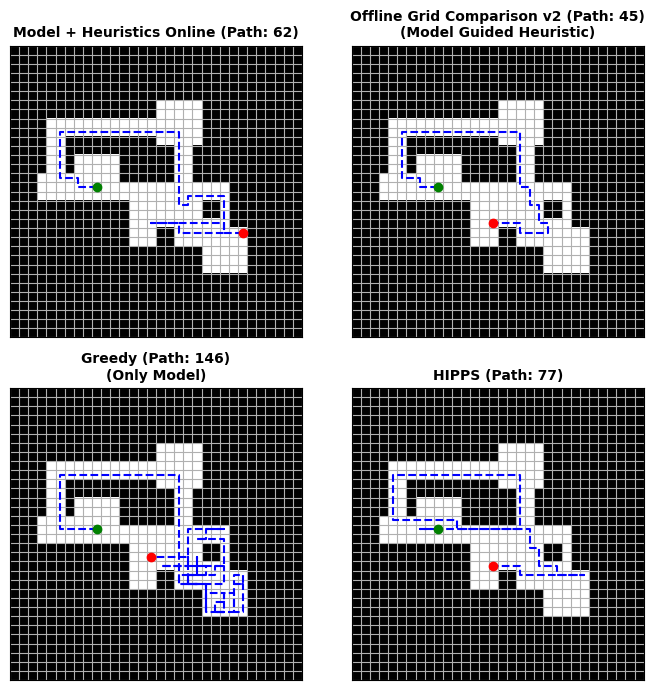

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))



# Algorithm 2: 
path_astar1 = receding_horizon_astar_online(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
plt.sca(axes[0, 0])
plot_path(grid, path_astar1)
axes[0, 0].set_title(f'Model + Heuristics Online (Path: {len(path_astar1)})', fontsize=10, fontweight='bold')

# Algorithm 3:
path_astar2 = receding_horizon_astar_online2(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
plt.sca(axes[0, 1])
plot_path(grid, path_astar2)
axes[0, 1].set_title(f'Offline Grid Comparison v2 (Path: {len(path_astar2)})\n(Model Guided Heuristic)', fontsize=10, fontweight='bold')

# Algorithm 1: Greedy Online
path_greedy, data_ = pred_path_greedy_online_flow(trained_model, grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
plt.sca(axes[1, 0])
plot_path(grid, path_greedy)
axes[1, 0].set_title(f'Greedy (Path: {len(path_greedy)})\n(Only Model)', fontsize=10, fontweight='bold')

# Algorithm 4: HIPPS
path_hipps = hipps_algorithm(grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
plt.sca(axes[1, 1])
plot_path(grid, path_hipps)
axes[1, 1].set_title(f'HIPPS (Path: {len(path_hipps)})', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [131]:
solver_opt = WRPSolverTSPJF(grid, start, los_type=LOS, vision_radius=8)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
lower_bound = len(path_opt) * 13/11
print("Lower Bound: ", lower_bound)
plot_path(grid, path_opt, start)

KeyboardInterrupt: 

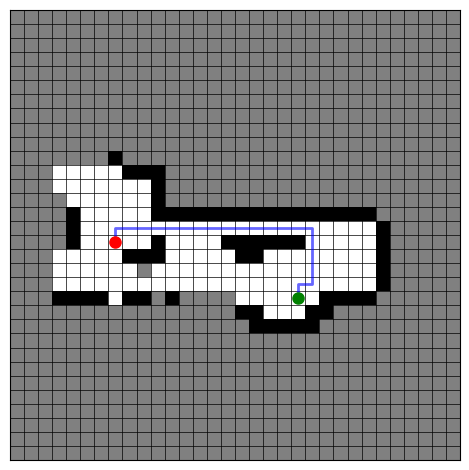

In [88]:
plot_visibility2(grid, path_astar1[:22], los_type=LOS, vision_radius=VISION_RADIUS, grazing_walls=True)

## Evaluation

In [ ]:
gtData = np.load("data/wrp_gt_data_16x16_los_square360_vision_8_141_samples_holes.npy", allow_pickle=True).item()


In [92]:
from data_generator import _solve_grid
def evaluate_model_on_random_grids(model, polygon_type = "simple_polygon", user_neural_search=True, num_samples=5, precomputed_gt=None):
     model.eval()
     grid_size = (16, 16)
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []
     pred_path_lengths_hipps = []
     pred_path_lengths_search_offline_comp = []
     # pred_path_lengths_visibility = []
     if precomputed_gt is not None:
          print("Using precomputed ground truth data for evaluation.")
          num_samples = min(num_samples, len(precomputed_gt["grid"]))

     files = os.listdir("data/DungeonMaps/test")
          
     print(f"Evaluating on {num_samples} samples")
     random_indices = np.random.choice(files, size=num_samples, replace=False)

     for i in tqdm(range(num_samples)):

          if precomputed_gt is None:
               
               grid, start = image_to_grid2(os.path.join("data/DungeonMaps/test", random_indices[i]))
               path_opt = [[int(start[0]), int(start[1])]]
               
          path_pred_line, _ = pred_path_greedy_online_flow(model, grid, start, max_steps=256, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS)
          if (user_neural_search):
               path_pred_line_search = receding_horizon_astar_online(model, grid, start, verbose=False ,los_type=LOS, vision_radius=VISION_RADIUS)
               path_pred_line_search2 = receding_horizon_astar_online2(model, grid, start, verbose=False ,los_type=LOS, vision_radius=VISION_RADIUS)
          hipps_pred_line = hipps_algorithm(grid, start, verbose=False, los_type=LOS, vision_radius=VISION_RADIUS)
          

          if (len(path_opt) > len(path_pred_line) or len(path_opt) > len(hipps_pred_line)):
               print(f"DISCREPANCY Sample {i}: Predicted: {len(path_pred_line)}, Optimal: {len(path_opt)}")
          else:
               gt_path_lengths.append(len(path_opt))
               pred_path_lengths.append(len(path_pred_line))
               pred_path_lengths_hipps.append(len(hipps_pred_line))
               pred_path_lengths_search_offline_comp.append(len(path_pred_line_search2))
               
               if user_neural_search: 
                    pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     print("HIPPS Predict Path Length: ", pred_path_lengths_hipps)
     # print("Visibility Predict Path Length: ", pred_path_lengths_visibility)
     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search), np.array(pred_path_lengths_hipps), np.array(pred_path_lengths_search_offline_comp)
     return np.array(gt_path_lengths), np.array(pred_path_lengths), None , np.array(pred_path_lengths_hipps)

In [ ]:
gt_path_lengths, pred_path_lengths, pred_path_lengths_search, pred_path_lengths_hipps, pred_path_lengths_search_offline_comp = evaluate_model_on_random_grids(trained_model, num_samples=101, precomputed_gt=None)

Evaluating on 101 samples


  0%|          | 0/101 [00:00<?, ?it/s]

Success! Entire polygon explored in 58 steps.


  1%|          | 1/101 [02:04<3:27:32, 124.53s/it]

Success! Entire polygon explored in 71 steps.


  2%|▏         | 2/101 [04:09<3:25:43, 124.68s/it]

Success! Entire polygon explored in 73 steps.


  3%|▎         | 3/101 [05:38<2:57:23, 108.61s/it]

Success! Entire polygon explored in 55 steps.


  4%|▍         | 4/101 [07:39<3:03:06, 113.27s/it]

In [ ]:
np.mean(gt_path_lengths), np.mean(pred_path_lengths), np.mean(pred_path_lengths_search), np.mean(pred_path_lengths_hipps), np.mean(pred_path_lengths_search_offline_comp)

(np.float64(1.0),
 np.float64(168.96039603960395),
 np.float64(74.21782178217822),
 np.float64(72.65346534653466),
 np.float64(58.693069306930695))

In [93]:
np.std(gt_path_lengths), np.std(pred_path_lengths), np.std(pred_path_lengths_search), np.std(pred_path_lengths_hipps), np.std(pred_path_lengths_search_offline_comp)

(np.float64(0.0),
 np.float64(81.75560304680116),
 np.float64(20.301004199127462),
 np.float64(20.52597274913674),
 np.float64(19.33177888187662))

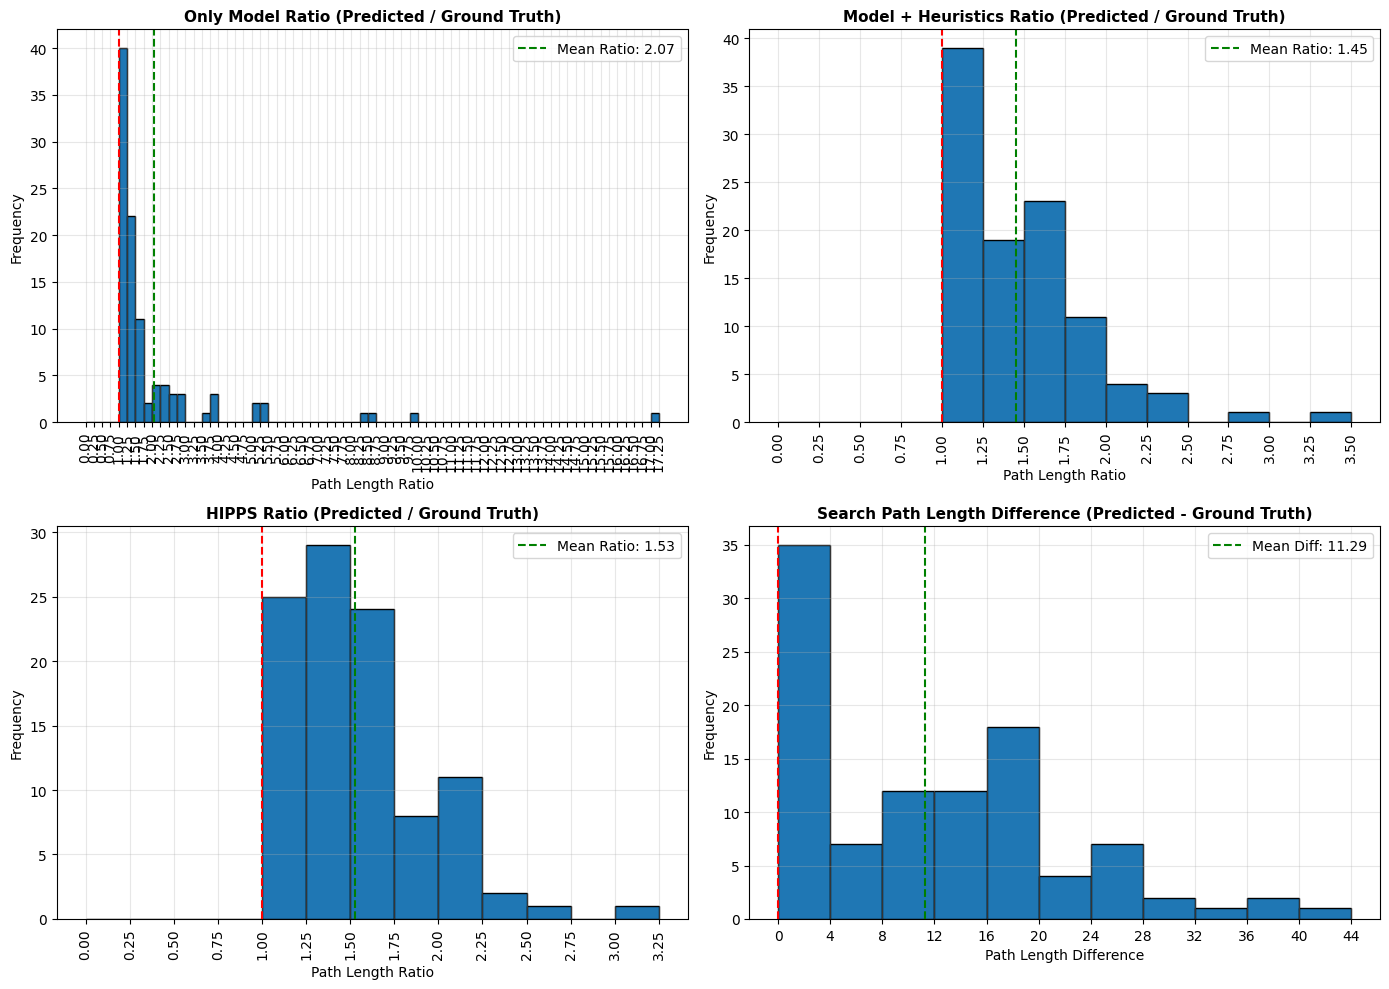

In [135]:
path_len_diff_model = pred_path_lengths - gt_path_lengths
path_len_ratio_model = pred_path_lengths / gt_path_lengths

path_len_diff_search = pred_path_lengths_search - gt_path_lengths
path_len_ratio_search = pred_path_lengths_search / gt_path_lengths

path_len_diff_hipps = pred_path_lengths_hipps - gt_path_lengths
path_len_ratio_hipps = pred_path_lengths_hipps / gt_path_lengths

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Ratio for Model
step = 0.25
axes[0, 0].hist(path_len_ratio_model, edgecolor='black', bins=np.arange(0, path_len_ratio_model.max() + step, step))
axes[0, 0].set_title("Only Model Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Path Length Ratio")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_model = np.mean(path_len_ratio_model)
axes[0, 0].axvline(expected_value_model, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_model:.2f}')
axes[0, 0].set_xticks(np.arange(0, path_len_ratio_model.max() + step, step))
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Ratio for Search
axes[0, 1].hist(path_len_ratio_search, edgecolor='black', bins=np.arange(0, path_len_ratio_search.max() + step, step))
axes[0, 1].set_title("Model + Heuristics Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Path Length Ratio")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_search = np.mean(path_len_ratio_search)
axes[0, 1].axvline(expected_value_search, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_search:.2f}')
axes[0, 1].set_xticks(np.arange(0, path_len_ratio_search.max() + step, step))
axes[0, 1].tick_params(axis='x', rotation=90)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Ratio for HIPPS
axes[1, 0].hist(path_len_ratio_hipps, edgecolor='black', bins=np.arange(0, path_len_ratio_hipps.max() + step, step))
axes[1, 0].set_title("HIPPS Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Path Length Ratio")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_hipps = np.mean(path_len_ratio_hipps)
axes[1, 0].axvline(expected_value_hipps, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_hipps:.2f}')
axes[1, 0].set_xticks(np.arange(0, path_len_ratio_hipps.max() + step, step))
axes[1, 0].tick_params(axis='x', rotation=90)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Path Length Difference for Search
step_diff = 4
axes[1, 1].hist(path_len_diff_search, edgecolor='black', bins=np.arange(path_len_diff_search.min(), path_len_diff_search.max() + step_diff, step_diff))
axes[1, 1].set_title("Search Path Length Difference (Predicted - Ground Truth)", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Path Length Difference")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].axvline(0, color='red', linestyle='dashed', linewidth=1.5)
expected_value = np.mean(path_len_diff_search)
axes[1, 1].axvline(expected_value, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Diff: {expected_value:.2f}')
axes[1, 1].set_xticks(np.arange(path_len_diff_search.min(), path_len_diff_search.max() + step_diff, step_diff))
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [141]:
save_evaluation_results(gt_path_lengths, pred_path_lengths, pred_path_lengths_search, pred_path_lengths_hipps, filename="evaluation_results/evaluation_results_grazing_simple_polygon5.npz")

Saved evaluation results to evaluation_results/evaluation_results_grazing_simple_polygon5.npz


In [131]:
gt_lengths1, pred_lengths_model1, pred_lengths_search1, pred_lengths_hipps1 = load_evaluation_results(filename="evaluation_results/evaluation_results_frontier_simple_polygon.npz")

Loaded evaluation results from evaluation_results/evaluation_results_frontier_simple_polygon.npz


## ## Learning on Polygon examples

In [24]:
from io import BytesIO
import joblib
import zlib

with open("data/Minimum_Feature_25_Dataset_Uniform_Continuous_SDF_Processed_Dataset/batch_1.pkl", "rb") as f:
    d0 = joblib.load(BytesIO(zlib.decompress(f.read())))
# (d0)

In [25]:
def create_polygon_batch(folder_path):
    polygons_pkl_files = os.listdir(folder_path)
    polygon_batch = {}
    for i in polygons_pkl_files:
        with open(os.path.join(folder_path, i), "rb") as f:
            polygon_batch[i] = joblib.load(BytesIO(f.read()))
    return polygon_batch

test_batch1 = create_polygon_batch("data/Specific_Type_Polygon_Test_25_Processed")
test_batch2 = create_polygon_batch("data/Minimum_Feature_25_Dataset_Test_New_Processed")


Randomly selected polygon index: 36 || Polygon key: 25_76_coords.pkl


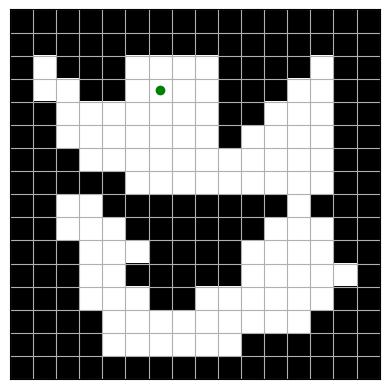

In [43]:
d0 = test_batch2
polygon_index = np.random.randint(0, len(d0) - 1)
k = list(d0.keys())[polygon_index]
print(f"Randomly selected polygon index: {polygon_index} || Polygon key: {k}")
polygon = d0[k]["level_2_polygon"]

grid_16, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)
# start from anywhere at random where there is no obstacle
free_cells = np.argwhere(grid_16 == 0)
start_index = np.random.choice(len(free_cells))
start_16 = tuple(free_cells[start_index])
plot_grid(grid_16, start_16)

Success! Entire polygon explored in 44 steps.
Success! Entire grid explored optimally in 44 steps.
Success! Entire polygon explored in 44 steps.
Success! Entire polygon explored in 71 steps.


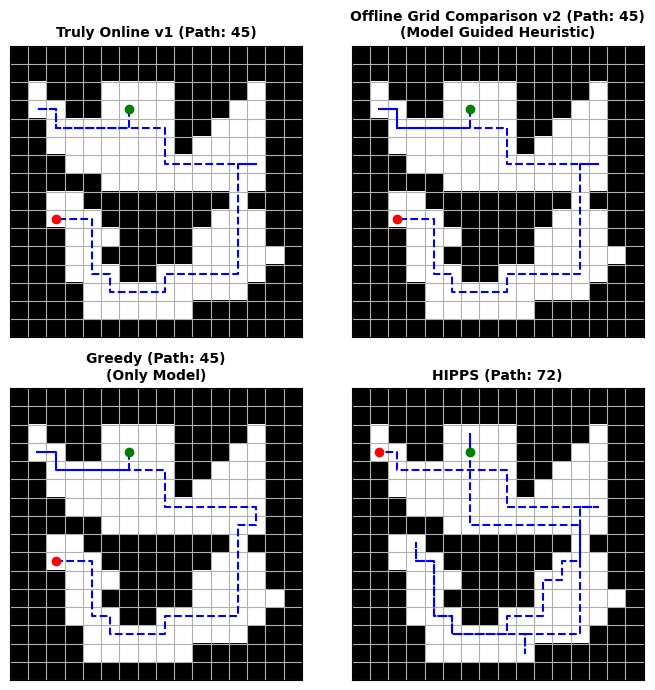

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))



# Algorithm 2: 
path_astar1 = receding_horizon_astar_online(trained_model, grid_16, start_16)
plt.sca(axes[0, 0])
plot_path(grid_16, path_astar1)
axes[0, 0].set_title(f'Truly Online v1 (Path: {len(path_astar1)})', fontsize=10, fontweight='bold')

# Algorithm 3:
path_astar2 = receding_horizon_astar_online2(trained_model, grid_16, start_16)
plt.sca(axes[0, 1])
plot_path(grid_16, path_astar2)
axes[0, 1].set_title(f'Offline Grid Comparison v2 (Path: {len(path_astar2)})\n(Model Guided Heuristic)', fontsize=10, fontweight='bold')

# Algorithm 1: Greedy Online
path_greedy, data_ = pred_path_greedy_online(trained_model, grid_16, start_16)
plt.sca(axes[1, 0])
plot_path(grid_16, path_greedy)
axes[1, 0].set_title(f'Greedy (Path: {len(path_greedy)})\n(Only Model)', fontsize=10, fontweight='bold')

# Algorithm 4: HIPPS
path_hipps = hipps_algorithm(trained_model, grid_16, start_16)
plt.sca(axes[1, 1])
plot_path(grid_16, path_hipps)
axes[1, 1].set_title(f'HIPPS (Path: {len(path_hipps)})', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Optimized Path Length: 38


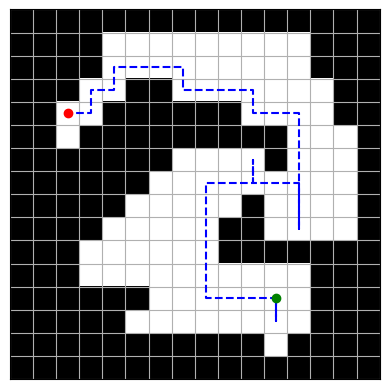

In [ ]:
solver_opt = WRPSolverTSPJF(grid_16, start_16)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
plot_path(grid_16, path_opt, start_16)

In [32]:
from data_generator import _solve_grid

def evaluate_model_on_visdiff_data(model, vis_diff_data_batch, user_neural_search=True, num_samples=5):
     model.eval()
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []
     pred_path_lengths_hipps = []
     # pred_path_lengths_visibility = []
     skipped = 0

     if (num_samples > len(vis_diff_data_batch) or num_samples <= 0):
          print(f"Requested num_samples ({num_samples}) exceeds available data ({len(vis_diff_data_batch)}). Evaluating on all available samples.")
          num_samples = len(vis_diff_data_batch)

     for k in tqdm(list(vis_diff_data_batch.keys())[:num_samples]):
          polygon = vis_diff_data_batch[k]["level_2_polygon"]
          grid, extent_16, fill_16 = polygon_to_obstacle_grid(polygon, grid_shape=(16, 16), samples_per_cell=8)

          # IMPORTANT: choose start from the current grid (not a stale global grid_16)
          free_cells = np.argwhere(grid == 0)
          if len(free_cells) == 0:
               continue

          start_index = np.random.choice(len(free_cells))
          start = tuple(map(int, free_cells[start_index]))

          path_opt = 257
          try:
               path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start), timeout=600)  # 10 minute timeout per sample
          except TimeoutError:
               print(f"Skipping: Sample {k}: Optimization timed out. Skipping this sample.")
               skipped += 1
               continue

          path_pred_line, _ = pred_path_greedy_online(model, grid, start, max_steps=256, verbose=False)
          if (user_neural_search):
               path_pred_line_search = receding_horizon_astar_online(model, grid, start, verbose=False)
          hipps_pred_line = hipps_algorithm(model, grid, start, verbose=False)
          

          gt_path_lengths.append(len(path_opt))
          pred_path_lengths.append(len(path_pred_line))
          pred_path_lengths_hipps.append(len(hipps_pred_line))
          
          if user_neural_search: 
               pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     print("HIPPS Predict Path Length: ", pred_path_lengths_hipps)

     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search), np.array(pred_path_lengths_hipps)
     return np.array(gt_path_lengths), np.array(pred_path_lengths), None , np.array(pred_path_lengths_hipps)

In [33]:
gt_path_lengths, pred_path_lengths_model, pred_path_lengths_search, pred_path_lengths_hipps = evaluate_model_on_visdiff_data(trained_model, test_batch2, user_neural_search=True, num_samples=-1)

Requested num_samples (-1) exceeds available data (300). Evaluating on all available samples.


100%|██████████| 300/300 [21:32<00:00,  4.31s/it] 


Average Ground Truth Path Length: 37.05
Average Predicted Path Length: 49.70
Root Mean Squared Error in Path Lengths: 24.48
Ground Truth Path Length:   [54, 45, 37, 33, 33, 25, 27, 48, 20, 29, 20, 48, 51, 39, 47, 16, 43, 53, 29, 40, 47, 20, 43, 31, 40, 41, 18, 40, 35, 27, 18, 26, 45, 78, 34, 40, 43, 49, 41, 50, 46, 23, 53, 30, 53, 59, 27, 46, 36, 35, 36, 54, 44, 18, 46, 25, 20, 19, 15, 51, 43, 30, 52, 44, 35, 39, 46, 19, 44, 55, 41, 18, 33, 41, 38, 45, 35, 58, 39, 53, 23, 43, 27, 18, 47, 47, 36, 51, 45, 39, 22, 20, 33, 23, 42, 38, 41, 42, 19, 21, 26, 33, 58, 37, 41, 56, 43, 16, 50, 26, 57, 27, 25, 36, 69, 46, 41, 58, 35, 50, 27, 17, 20, 39, 51, 52, 42, 37, 20, 20, 43, 41, 45, 48, 35, 38, 18, 37, 44, 42, 37, 15, 18, 16, 37, 37, 57, 51, 37, 51, 47, 19, 46, 42, 41, 17, 40, 27, 47, 36, 21, 27, 35, 16, 17, 33, 33, 29, 49, 50, 49, 45, 58, 49, 55, 17, 17, 46, 43, 15, 53, 42, 40, 16, 32, 46, 28, 49, 16, 20, 18, 42, 24, 28, 17, 45, 52, 41, 57, 40, 39, 46, 44, 21, 52, 24, 60, 34, 45, 30, 42, 53

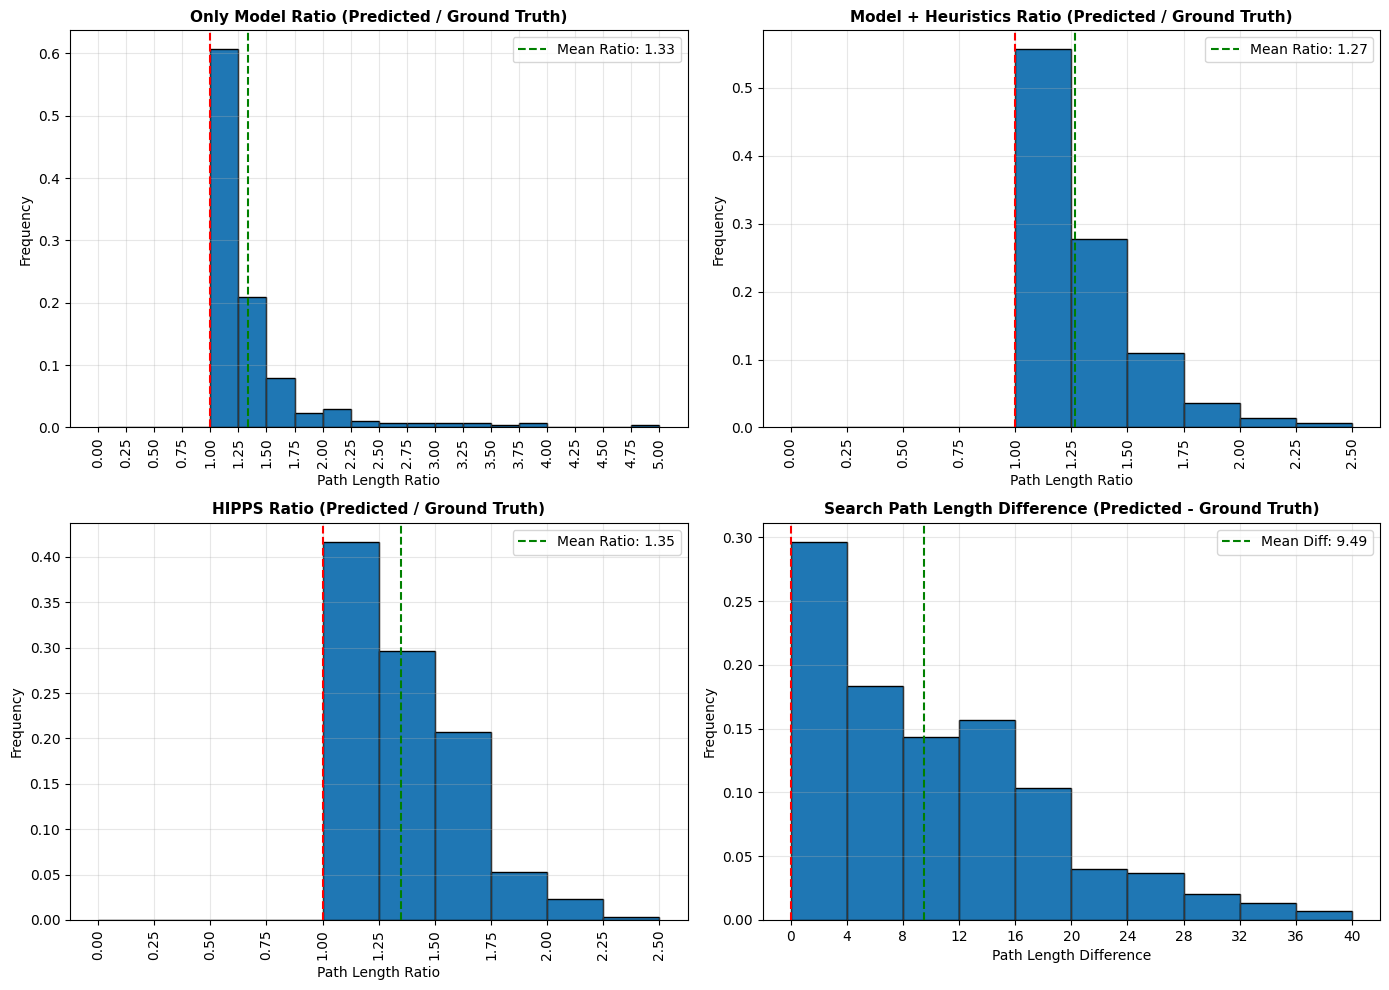

In [34]:
path_len_diff_model = pred_path_lengths_model - gt_path_lengths
path_len_ratio_model = pred_path_lengths_model / gt_path_lengths

path_len_diff_search = pred_path_lengths_search - gt_path_lengths
path_len_ratio_search = pred_path_lengths_search / gt_path_lengths

path_len_diff_hipps = pred_path_lengths_hipps - gt_path_lengths
path_len_ratio_hipps = pred_path_lengths_hipps / gt_path_lengths

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Ratio for Model
step = 0.25
weights = np.ones_like(path_len_ratio_model) / len(path_len_ratio_model)
axes[0, 0].hist(path_len_ratio_model, edgecolor='black', bins=np.arange(0, path_len_ratio_model.max() + step, step), weights=weights)
axes[0, 0].set_title("Only Model Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Path Length Ratio")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_model = np.mean(path_len_ratio_model)
axes[0, 0].axvline(expected_value_model, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_model:.2f}')
axes[0, 0].set_xticks(np.arange(0, path_len_ratio_model.max() + step, step))
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Ratio for Search
weights_search = np.ones_like(path_len_ratio_search) / len(path_len_ratio_search)
axes[0, 1].hist(path_len_ratio_search, edgecolor='black', bins=np.arange(0, path_len_ratio_search.max() + step, step), weights=weights_search)
axes[0, 1].set_title("Model + Heuristics Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Path Length Ratio")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_search = np.mean(path_len_ratio_search)
axes[0, 1].axvline(expected_value_search, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_search:.2f}')
axes[0, 1].set_xticks(np.arange(0, path_len_ratio_search.max() + step, step))
axes[0, 1].tick_params(axis='x', rotation=90)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Ratio for HIPPS
weights_hipps = np.ones_like(path_len_ratio_hipps) / len(path_len_ratio_hipps)
axes[1, 0].hist(path_len_ratio_hipps, edgecolor='black', bins=np.arange(0, path_len_ratio_hipps.max() + step, step), weights=weights_hipps)
axes[1, 0].set_title("HIPPS Ratio (Predicted / Ground Truth)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Path Length Ratio")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].axvline(1, color='red', linestyle='dashed', linewidth=1.5)
expected_value_hipps = np.mean(path_len_ratio_hipps)
axes[1, 0].axvline(expected_value_hipps, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Ratio: {expected_value_hipps:.2f}')
axes[1, 0].set_xticks(np.arange(0, path_len_ratio_hipps.max() + step, step))
axes[1, 0].tick_params(axis='x', rotation=90)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Path Length Difference for Search
step_diff = 4
weights_diff_search = np.ones_like(path_len_diff_search) / len(path_len_diff_search)
axes[1, 1].hist(path_len_diff_search, edgecolor='black', bins=np.arange(path_len_diff_search.min(), path_len_diff_search.max() + step_diff, step_diff), weights=weights_diff_search)
axes[1, 1].set_title("Search Path Length Difference (Predicted - Ground Truth)", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Path Length Difference")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].axvline(0, color='red', linestyle='dashed', linewidth=1.5)
expected_value = np.mean(path_len_diff_search)
axes[1, 1].axvline(expected_value, color='green', linestyle='dashed', linewidth=1.5, label=f'Mean Diff: {expected_value:.2f}')
axes[1, 1].set_xticks(np.arange(path_len_diff_search.min(), path_len_diff_search.max() + step_diff, step_diff))
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
save_evaluation_results(pred_path_lengths_model, pred_path_lengths_model, pred_path_lengths_search, pred_path_lengths_hipps, filename="data/vis_diff_evaluation_results_grazing_simple_polygon.npz")

In [ ]:
from data_generator import _solve_grid
def generate_n_samples_where_model_is_above_threshold(model, num_samples, threshold = 1.5):
    X_list = []
    y_list = []
    skipped = 0
    count = 0
    for _ in tqdm(range(num_samples)):
        grid, start = gen.generate_simple_polygon_grid()
        
        path_opt = 257
        try:
            path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start), timeout=600)  # 10 minute timeout per sample
        except TimeoutError:
            print(f"Skipping: Sample {k}: Optimization timed out. Skipping this sample.")
            skipped += 1
            continue
        path_pred_line, _ = pred_path_greedy_online(model, grid, start, max_steps=256, verbose=False)
        
        pred_path_length = len(path_pred_line)
        gt_path_length = len(path_opt)
        if pred_path_length/gt_path_length > threshold:
            X, y = generate_training_data_for_online_learning(grid, path_opt, discounted_step=10, grazing_walls=True) 
            X_list.append(torch.tensor(X, dtype=torch.float32))
            y_list.append(torch.tensor(y, dtype=torch.float32))
            count += 1
        
    print(f"Generated {count} samples, skipped {skipped} samples due to timeout.")
    if count == 0:
        print("No samples generated. Consider lowering the threshold.")
        return None, None
    return torch.cat(X_list), torch.cat(y_list) 

X_train_hard, y_train_hard = generate_n_samples_where_model_is_above_threshold(trained_model, 1000)


In [3]:
X_train_hard1, y_train_hard1 =load_data_from_disk("data/wrp_online_grazing_data_16x16_74_samples_SP_train_hard1.pt")
print(f"Loaded hard sample dataset with {len(X_train_hard1)} samples.")
X_train_hard2, y_train_hard2 =load_data_from_disk("data/wrp_online_grazing_data_16x16_163_samples_SP_train_hard2.pt")
print(f"Loaded hard sample dataset with {len(X_train_hard2)} samples.")

Loaded 2322 samples from data/wrp_online_grazing_data_16x16_74_samples_SP_train_hard1.pt
X shape: (2322, 3, 16, 16) | y shape: (2322, 1, 16, 16)
Loaded hard sample dataset with 2322 samples.
Loaded 5228 samples from data/wrp_online_grazing_data_16x16_163_samples_SP_train_hard2.pt
X shape: (5228, 3, 16, 16) | y shape: (5228, 1, 16, 16)
Loaded hard sample dataset with 5228 samples.


In [4]:
X_train_hard, y_train_hard = torch.cat([X_train_hard1, X_train_hard2]), torch.cat([y_train_hard1, y_train_hard2])
print(f"Combined hard sample dataset has {len(X_train_hard)} samples.")

Combined hard sample dataset has 7550 samples.


In [5]:
save_data_to_disk(X_train_hard, y_train_hard, file_path = "data/wrp_online_grazing_data_16x16_230_samples_SP_train_hard.pt")

Saved 7550 samples to data/wrp_online_grazing_data_16x16_230_samples_SP_train_hard.pt
X shape: (7550, 3, 16, 16) | y shape: (7550, 1, 16, 16)


'data/wrp_online_grazing_data_16x16_230_samples_SP_train_hard.pt'